In [2]:
import numpy as np
from numpy import abs
import matplotlib.pyplot as plt
import sys
from pathlib import Path
# Use __file__ if running as a script, or fallback to the current working directory if in Jupyter
current_dir = Path(__file__).resolve() if '__file__' in locals() else Path.cwd()
# Go up two levels to get the root directory
root_dir = current_dir.parents[1] if '__file__' in locals() else current_dir.parent
# Safely inject the directory to Python's search path
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))
from singles import OptimalPhase, FisherInfo, OptFisherInfo

#* Variables
G=np.linspace(1e-2,10,300)          #? Gain
T = 0.8                             #? |τ|^2
t_s1=np.sqrt(T)                     #? τ_s1
t_i1=np.sqrt(T)                     #? τ_i1
t_s2=np.sqrt(T)                     #? τ_s2
a_i=1                               #? α_i

phi = OptimalPhase(a_i=a_i, G=G, t_s1=t_s1, t_i1=t_i1, t_s2=t_s2) 
F = OptFisherInfo(a_i=a_i, G=G, t_s1=t_s1, t_i1=t_i1, t_s2=t_s2) 

#* High Gain limit of optimal phase: lim(G->Inf) φ_opt
phi_max = np.arccos(-(2*abs(t_s1)*abs(t_i1))/((abs(t_s1)**2+abs(t_i1)**2)))

#* Total Number of down-converted photons: <N_{dc}^{α}>
Ndc=2*abs(np.sinh(G))**2*(1+abs(a_i)**2)+abs(a_i)**2

#* Fixed Phase values that will be used in the plots
colors=["yellowgreen","orange","deepskyblue","blueviolet"]
phases=np.array([3.14, 3, 2.23])

[Text(1, 2.356194490192345, '$\\frac{3}{4}\\pi$'),
 Text(1, 3.141592653589793, '$\\pi$')]

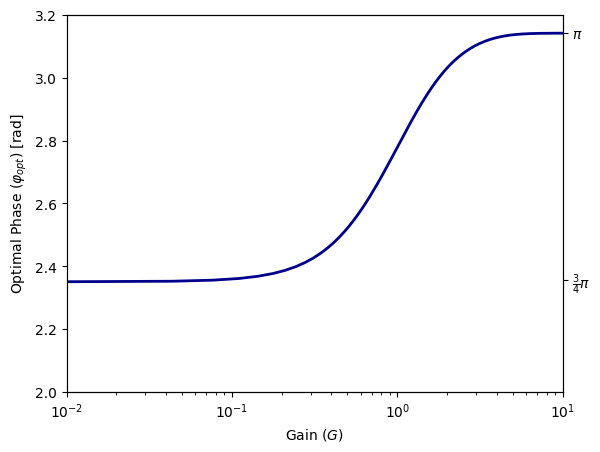

In [3]:
fig,ax = plt.subplots()
fig.set_figheight(4.9)
ax.plot(G,phi, color="darkblue", label=r"$\varphi_{opt}(G)$", linewidth=2)
ax.set_xlabel(r'Gain ($G$)')
ax.set_xlim([G.min(),G.max()])
ax.set_xscale("log")
ax.set_ylabel(r'Optimal Phase ($\varphi_{opt})$ [rad]') 
ax.set_ylim((2,3.2))
#ax.axhline(phi_max,color="royalblue",linestyle=":")

twinax = ax.twinx() 
twinax.set_ylim(ax.get_ylim())
twinax.set_yticks([3/4*np.pi,np.pi])
twinax.set_yticklabels([r"$\frac{3}{4}\pi$",r"$\pi$"])


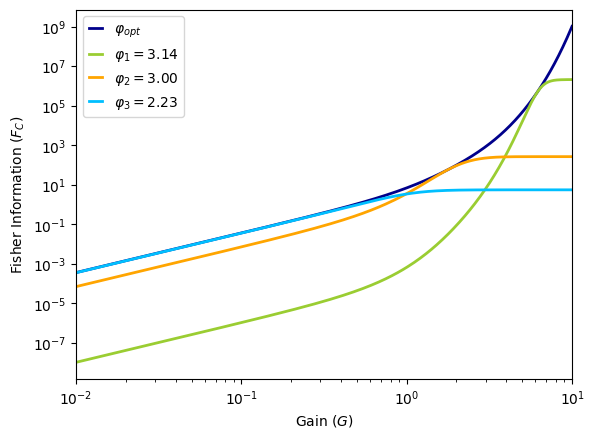

In [15]:
fig,ax = plt.subplots()
ax.plot(G,F, color="darkblue", label=r"$\varphi_{opt}$",linewidth=2)
ax.set_xlabel(r'Gain ($G$)')
ax.set_xlim([G.min(),G.max()])
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel(r"Fisher Information ($F_C$)")

for i in range(len(phases)):
   f = FisherInfo(phi=phases[i], a_i=a_i, G=G, t_s1=t_s1, t_i1=t_i1, t_s2=t_s2) 
   ax.plot(G,f,color=colors[i],label=rf"$\varphi_{i+1}={phases[i]:.2f}$", linewidth=2)

ax.legend(handlelength=1)

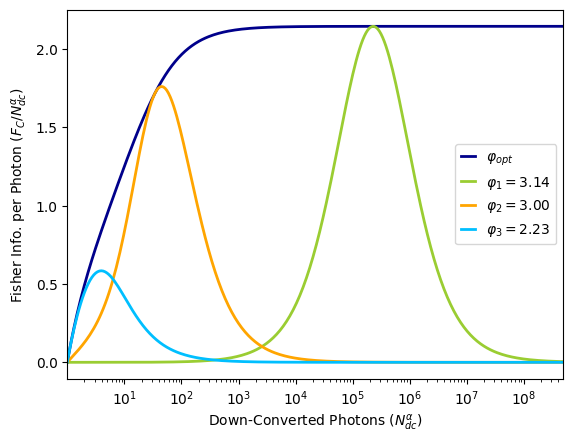

In [ ]:
fig,ax = plt.subplots()
ax.plot(Ndc,F/Ndc, color="darkblue", label=r"$\varphi_{opt}$", linewidth=2)
ax.set_xlim([Ndc.min(),Ndc.max()])
ax.set_xscale("log")
#ax.set_xlabel(r'Down-Converted Photons ($N_{dc}^0$)')
#ax.set_ylabel(r"Fisher Info. per Photon ($F_C/N_{dc}^0$)")
ax.set_xlabel(r'Down-Converted Photons ($N_{dc}^\alpha$)')
ax.set_ylabel(r"Fisher Info. per Photon ($F_C/N_{dc}^\alpha$)")

for i in range(len(phases)):
   f = FisherInfo(phi=phases[i], a_i=a_i, G=G, t_s1=t_s1, t_i1=t_i1, t_s2=t_s2) 
   ax.plot(Ndc,f/Ndc,color=colors[i],label=rf"$\varphi_{i+1}={phases[i]:.2f}$", linewidth=2)

ax.legend(handlelength=1)

Text(0.5, 0, 'Down-Converted Photons ($N_{dc}^0$)')

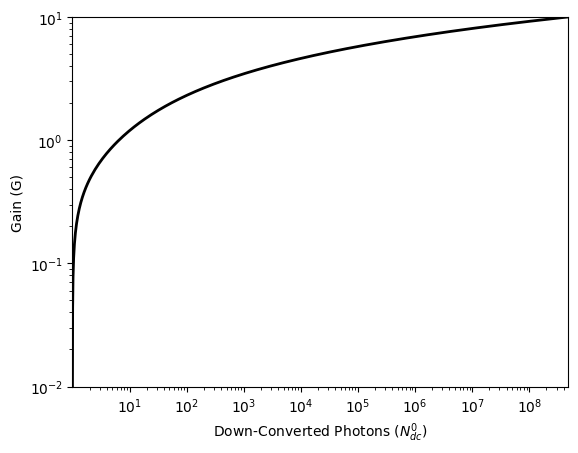

In [ ]:
fig,ax = plt.subplots()
ax.plot(Ndc,G, color="black", linewidth=2)
ax.set_xlim([Ndc.min(),Ndc.max()])
ax.set_ylim((G.min(),G.max()))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel(r'Gain (G)')

ax.set_xlabel(r'Down-Converted Photons ($N_{dc}^0$)')